# Exercício 5 — Análise de Sentimento com RNNs (LSTM/GRU)

**Curso de Deep Learning — 2025.2 Graduação**

Classificação binária de sentimento no dataset IMDB 50k usando BiLSTM e BiGRU bidirecionais com self-attention, comparando embeddings aprendidos (100d) vs pré-treinados GloVe (300d).

**Relatório completo:** [`docs_pt/RELATORIO.md`](docs_pt/RELATORIO.md)

## Fundamentos: RNN, LSTM e GRU

### RNN Simples (Vanilla)

A RNN processa uma sequência token a token, mantendo um estado oculto hₜ que é atualizado a cada passo:

```
hₜ = tanh(W_xh · xₜ + W_hh · hₜ₋₁ + b_h)
yₜ = W_hy · hₜ + b_y
```

onde xₜ é o input no tempo t, hₜ₋₁ é o estado anterior, e W_xh, W_hh, W_hy são matrizes de pesos aprendidas.

**Problema: Vanishing Gradient.** Durante o backpropagation through time (BPTT), o gradiente da loss em relação a hₜ é propagado por toda a sequência. A cada passo, ele é multiplicado por W_hh e pela derivada da tanh (que é sempre ≤ 1). Após T passos:

```
∂L/∂h₁ = ∂L/∂hₜ · ∏ₖ₌₂ᵀ (W_hh · diag(tanh'(hₖ)))
```

Com T = 300 (nosso comprimento de sequência), esse produto de matrizes faz o gradiente **desaparecer exponencialmente** → o modelo não consegue aprender dependências de longa distância como "I was expecting this to be terrible but it turned out to be **amazing**".

---

### LSTM — Long Short-Term Memory (Hochreiter & Schmidhuber, 1997)

A LSTM resolve o vanishing gradient introduzindo uma **célula de memória** (cₜ) separada e **3 gates** que controlam o fluxo de informação:

```
fₜ = σ(W_f · [hₜ₋₁, xₜ] + b_f)          ← forget gate
iₜ = σ(W_i · [hₜ₋₁, xₜ] + b_i)          ← input gate
c̃ₜ = tanh(W_c · [hₜ₋₁, xₜ] + b_c)       ← candidato
cₜ = fₜ ⊙ cₜ₋₁ + iₜ ⊙ c̃ₜ               ← atualização da memória
oₜ = σ(W_o · [hₜ₋₁, xₜ] + b_o)          ← output gate
hₜ = oₜ ⊙ tanh(cₜ)                       ← hidden state
```

onde σ é a sigmoid (saída entre 0 e 1) e ⊙ é multiplicação elemento a elemento.

**Por que resolve o vanishing gradient?** A atualização de cₜ é uma **soma** (não multiplicação repetida por W_hh). Se fₜ ≈ 1 e iₜ ≈ 0, a célula simplesmente copia cₜ₋₁ → o gradiente flui de volta sem atenuação, como uma "highway" para a informação.

**Intuição dos gates para sentimento:**
- **Forget gate (fₜ):** ao ler "however" numa resenha positiva, esquece o contexto positivo anterior
- **Input gate (iₜ):** ao encontrar "masterpiece", abre para gravar essa informação forte
- **Output gate (oₜ):** decide o que da memória é relevante para o próximo token

---

### GRU — Gated Recurrent Unit (Cho et al., 2014)

O GRU simplifica a LSTM para **2 gates** e sem célula de memória separada:

```
zₜ = σ(W_z · [hₜ₋₁, xₜ] + b_z)          ← update gate
rₜ = σ(W_r · [hₜ₋₁, xₜ] + b_r)          ← reset gate
h̃ₜ = tanh(W_h · [rₜ ⊙ hₜ₋₁, xₜ] + b_h)  ← candidato
hₜ = zₜ ⊙ hₜ₋₁ + (1 - zₜ) ⊙ h̃ₜ         ← interpolação
```

**Update gate (zₜ):** faz o papel do forget + input gate. Se zₜ = 1, copia hₜ₋₁ intacto (preserva memória). Se zₜ = 0, substitui pelo candidato. Os coeficientes zₜ e (1 - zₜ) sempre somam 1 → estabiliza o gradiente.

**Reset gate (rₜ):** controla quanto do estado anterior entra no cálculo do candidato. Se rₜ = 0, "reseta" e age como se fosse o primeiro token.

---

### Comparação

| Aspecto | RNN | LSTM | GRU |
|---------|-----|------|-----|
| Gates | 0 | 3 (forget, input, output) | 2 (update, reset) |
| Estado | hₜ | hₜ + cₜ (memória separada) | hₜ |
| Parâmetros (nossa config) | — | 2.6M | 2.5M |
| Vanishing gradient | Grave | Resolvido (highway via cₜ) | Resolvido (interpolação via zₜ) |
| Velocidade | Rápida | Média | Similar ao LSTM |

Nos nossos experimentos, LSTM supera GRU por ~0.5% — diferença marginal, indicando que a tarefa não é complexa o suficiente para o gate extra do LSTM fazer diferença significativa. Ambos resolvem o problema fundamental: **manter na memória que um "not" no início da frase nega um "good" 200 tokens adiante**.

## 1. Setup e Configuração

In [1]:
import html
import json
import re
import random
import time
import urllib.request
import zipfile
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
print(f"MPS: {hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()}")

PyTorch: 2.8.0
CUDA: False
MPS: True


In [2]:
# --- Constantes e reprodutibilidade ---

SEED = 42
PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"
PAD_IDX, UNK_IDX = 0, 1
GLOVE_DIM = 300
GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

@dataclass
class Config:
    rnn_type: str = "LSTM"
    use_glove: bool = False
    vocab_size: int = 20_000
    embed_dim: int = 100
    hidden_dim: int = 128
    n_layers: int = 2
    bidirectional: bool = True
    dropout: float = 0.5
    max_seq_len: int = 300
    batch_size: int = 64
    lr: float = 1e-3
    num_epochs: int = 15
    patience: int = 5
    grad_clip: float = 1.0
    seed: int = SEED

    @property
    def name(self):
        direction = "Bi" if self.bidirectional else ""
        emb = "GloVe" if self.use_glove else "Learned"
        return f"{direction}{self.rnn_type}-{emb}"

set_seed()
device = get_device()
print(f"Device: {device}")
print(f"Seed: {SEED}")

Device: mps
Seed: 42


## 2. Pré-processamento dos Dados

Pipeline de limpeza:
1. Decodificação de entidades HTML
2. Remoção de tags HTML
3. Lowercase
4. Remoção de caracteres não-alfabéticos
5. Tokenização por whitespace

**Sem remoção de stopwords** (palavras de negação como "not" carregam sentimento) e **sem stemming** (vocabulário de 20k é suficiente).

In [3]:
def preprocess_review(text):
    """Limpa e tokeniza uma resenha."""
    text = html.unescape(text)              # &amp; -> &
    text = re.sub(r"<[^>]+>", " ", text)    # remove tags HTML
    text = text.lower()                      # lowercase
    text = re.sub(r"[^a-z\s]", " ", text)   # remove não-alfabéticos
    return text.split()                      # tokeniza por whitespace

# Carrega dataset
csv_path = "IMDB Dataset.csv"
df = pd.read_csv(csv_path)
print(f"Total de resenhas: {len(df)}")
print(f"\nDistribuição de sentimento:")
print(df["sentiment"].value_counts())

# Converte labels para binário
labels = np.array((df["sentiment"] == "positive").astype(int))

# Tokeniza todas as resenhas
tokenized = [preprocess_review(r) for r in df["review"]]
original_reviews = df["review"].tolist()

# Estatísticas de comprimento
lengths = [len(t) for t in tokenized]
print(f"\nComprimento dos tokens:")
print(f"  Média: {np.mean(lengths):.0f}, Mediana: {np.median(lengths):.0f}")
print(f"  Percentil 75: {np.percentile(lengths, 75):.0f}, 90: {np.percentile(lengths, 90):.0f}")
print(f"  Min: {np.min(lengths)}, Max: {np.max(lengths)}")

Total de resenhas: 50000

Distribuição de sentimento:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64



Comprimento dos tokens:
  Média: 234, Mediana: 176
  Percentil 75: 284, 90: 457
  Min: 6, Max: 2494


In [4]:
# Exemplo: antes e depois do pré-processamento
raw = df["review"].iloc[0]
print("ANTES (primeiros 300 chars):")
print(raw[:300])
print("\nDEPOIS (primeiros 30 tokens):")
print(tokenized[0][:30])

ANTES (primeiros 300 chars):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

DEPOIS (primeiros 30 tokens):
['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'you', 'll', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me', 'the', 'first']


## 3. Vocabulário e Codificação

Construímos um vocabulário das 20.000 palavras mais frequentes (cobertura ~97,6%). Palavras fora do vocabulário são mapeadas para `<unk>`. Sequências são truncadas/padded para 300 tokens.

In [5]:
def build_vocabulary(tokenized_reviews, vocab_size):
    """Constrói mapeamentos word2idx e idx2word das palavras mais frequentes."""
    counter = Counter()
    for tokens in tokenized_reviews:
        counter.update(tokens)

    most_common = counter.most_common(vocab_size)

    word2idx = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
    for i, (word, _) in enumerate(most_common):
        word2idx[word] = i + 2

    idx2word = {v: k for k, v in word2idx.items()}
    return word2idx, idx2word

def encode_reviews(tokenized_reviews, word2idx, max_seq_len):
    """Converte tokens em sequências de inteiros com padding."""
    encoded = np.full((len(tokenized_reviews), max_seq_len), PAD_IDX, dtype=np.int64)
    for i, tokens in enumerate(tokenized_reviews):
        indices = [word2idx.get(t, UNK_IDX) for t in tokens[:max_seq_len]]
        encoded[i, :len(indices)] = indices
    return encoded

config = Config()
word2idx, idx2word = build_vocabulary(tokenized, config.vocab_size)

# Cobertura do vocabulário
total_tokens = sum(len(t) for t in tokenized)
covered = sum(1 for t in tokenized for w in t if w in word2idx)
print(f"Vocabulário: {config.vocab_size} palavras (de {len(set(w for t in tokenized for w in t))} únicas)")
print(f"Cobertura: {covered/total_tokens:.1%}")
print(f"Top 10 palavras: {list(word2idx.keys())[2:12]}")

# Codifica
sequences = encode_reviews(tokenized, word2idx, config.max_seq_len)
print(f"\nShape codificado: {sequences.shape}")
print(f"Exemplo (primeiros 20 índices): {sequences[0][:20]}")

Vocabulário: 20000 palavras (de 99420 únicas)
Cobertura: 97.6%
Top 10 palavras: ['the', 'and', 'a', 'of', 'to', 'is', 'it', 'in', 'i', 'this']



Shape codificado: (50000, 300)
Exemplo (primeiros 20 índices): [  29    5    2   78 2038   47 1052   12  101  150   42 3057  395   21
  230   30 3174   33   26  205]


## 4. DataLoaders (Train/Val/Test)

Split estratificado 80/10/10 preservando o balanço de classes.

In [6]:
class IMDBDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

def create_dataloaders(sequences, labels, batch_size, seed=SEED):
    """Split 80/10/10 estratificado e cria DataLoaders."""
    indices = np.arange(len(labels))
    train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=seed, stratify=labels)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=seed, stratify=labels[temp_idx])

    train_loader = DataLoader(IMDBDataset(sequences[train_idx], labels[train_idx]), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(IMDBDataset(sequences[val_idx], labels[val_idx]), batch_size=batch_size)
    test_loader = DataLoader(IMDBDataset(sequences[test_idx], labels[test_idx]), batch_size=batch_size)

    return train_loader, val_loader, test_loader, train_idx, val_idx, test_idx

train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
    sequences, labels, config.batch_size
)
print(f"Treino: {len(train_idx)}, Validação: {len(val_idx)}, Teste: {len(test_idx)}")
print(f"Batches — treino: {len(train_loader)}, val: {len(val_loader)}, teste: {len(test_loader)}")

Treino: 40000, Validação: 5000, Teste: 5000
Batches — treino: 625, val: 79, teste: 79


## 5. Embeddings GloVe

Download e carregamento dos vetores pré-treinados GloVe-6B-300d (Stanford NLP). Cobertura de 99,5% do nosso vocabulário.

In [7]:
GLOVE_DIR = Path("glove")

def download_glove():
    """Baixa e extrai embeddings GloVe se necessário."""
    GLOVE_DIR.mkdir(exist_ok=True)
    glove_file = GLOVE_DIR / f"glove.6B.{GLOVE_DIM}d.txt"

    if glove_file.exists():
        print(f"GloVe já existe: {glove_file}")
        return glove_file

    zip_path = GLOVE_DIR / "glove.6B.zip"
    if not zip_path.exists():
        print(f"Baixando GloVe de {GLOVE_URL}...")
        print("(~862 MB, pode levar alguns minutos)")
        urllib.request.urlretrieve(GLOVE_URL, zip_path)

    print(f"Extraindo glove.6B.{GLOVE_DIM}d.txt...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extract(f"glove.6B.{GLOVE_DIM}d.txt", GLOVE_DIR)

    return glove_file

def load_glove_embeddings(word2idx, embed_dim):
    """Constrói matriz de embedding alinhada com nosso vocabulário."""
    glove_path = download_glove()
    print(f"Carregando GloVe-{embed_dim}d...")

    glove_vectors = {}
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            if word in word2idx:
                glove_vectors[word] = np.array(parts[1:], dtype=np.float32)

    vocab_total = len(word2idx)
    embedding_matrix = torch.randn(vocab_total, embed_dim) * 0.6
    embedding_matrix[PAD_IDX] = torch.zeros(embed_dim)

    found = 0
    for word, idx in word2idx.items():
        if word in glove_vectors:
            embedding_matrix[idx] = torch.from_numpy(glove_vectors[word])
            found += 1

    print(f"Cobertura GloVe: {found}/{vocab_total} palavras ({found/vocab_total:.1%})")
    return embedding_matrix

# Pré-carrega GloVe (usado nos experimentos com GloVe)
glove_embeddings = load_glove_embeddings(word2idx, GLOVE_DIM)

GloVe já existe: glove/glove.6B.300d.txt
Carregando GloVe-300d...


Cobertura GloVe: 19911/20002 palavras (99.5%)


## 6. Arquitetura do Modelo

BiLSTM/BiGRU bidirecional com **self-attention** + **mean pooling** + **max pooling** sobre todos os hidden states. A concatenação dos 3 vetores (256 × 3 = 768d) alimenta a camada de classificação.

```
Entrada (batch, 300)
  → Embedding + Dropout(0.3)
  → BiLSTM/BiGRU (2 camadas, hidden=128)
  → [Self-Attention ‖ Mean Pool ‖ Max Pool] → (batch, 768)
  → Dropout(0.5) → Linear(768, 1) → Sigmoid
```

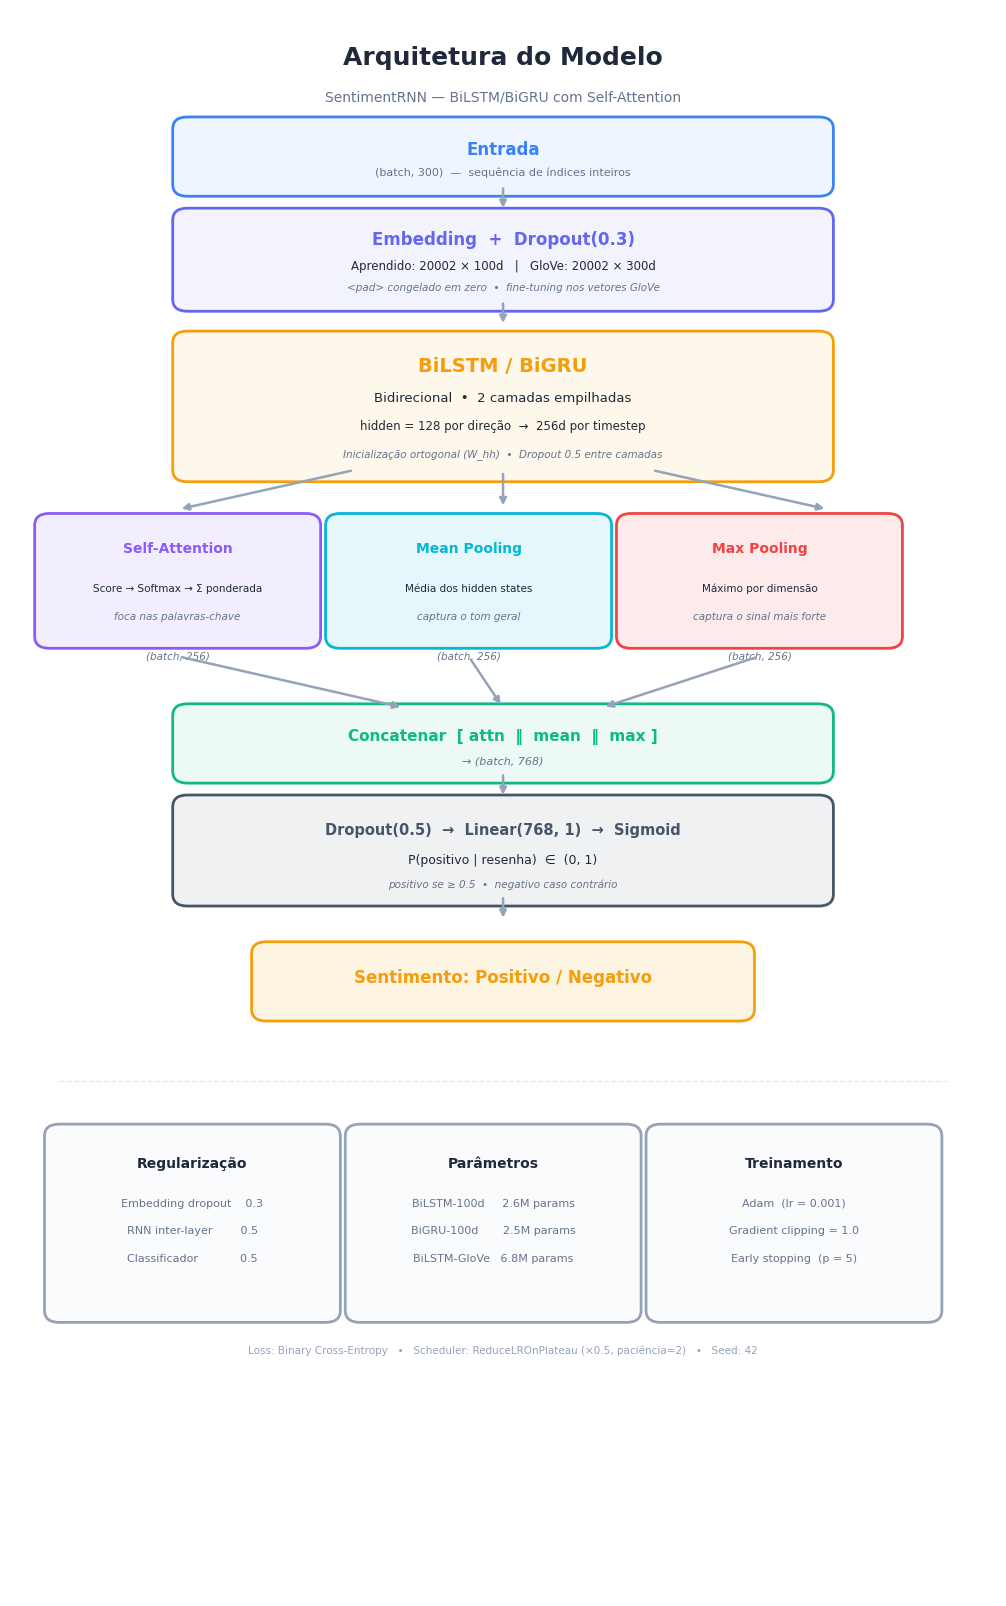

Salvo em plots/architecture.png


In [8]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis("off")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# --- Color palette ---
C = {
    "input":  "#3B82F6",
    "embed":  "#6366F1",
    "rnn":    "#F59E0B",
    "attn":   "#8B5CF6",
    "mean":   "#06B6D4",
    "max":    "#EF4444",
    "concat": "#10B981",
    "class":  "#475569",
    "out":    "#F59E0B",
}
TEXT = "#1E293B"
SUB = "#64748B"

def box(x, y, w, h, color, alpha=0.08):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.15",
        facecolor=(*plt.cm.colors.to_rgb(color), alpha),
        edgecolor=color, linewidth=2
    )
    ax.add_patch(rect)

def txt(x, y, s, size=10, color=TEXT, weight="normal", **kw):
    ax.text(x, y, s, fontsize=size, color=color, fontweight=weight,
            ha="center", va="center", fontfamily="sans-serif", **kw)

def arr(x1, y1, x2, y2, color="#94A3B8"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.8,
                                shrinkA=3, shrinkB=3))

CX = 5
BW = 6.4   # box width
BX = CX - BW/2  # box left x

# ── Title ──
txt(CX, 19.4, "Arquitetura do Modelo", size=18, weight="bold")
txt(CX, 18.9, "SentimentRNN — BiLSTM/BiGRU com Self-Attention", size=10, color=SUB)

# ── Input ──
y = 17.8
box(BX, y, BW, 0.7, C["input"])
txt(CX, y+0.43, "Entrada", size=12, weight="bold", color=C["input"])
txt(CX, y+0.15, "(batch, 300)  —  sequência de índices inteiros", size=8, color=SUB)

arr(CX, y, CX, y-0.35)

# ── Embedding ──
y = 16.35
box(BX, y, BW, 1.0, C["embed"])
txt(CX, y+0.75, "Embedding  +  Dropout(0.3)", size=12, weight="bold", color=C["embed"])
txt(CX, y+0.42, "Aprendido: 20002 × 100d   |   GloVe: 20002 × 300d", size=8.5, color=TEXT)
txt(CX, y+0.15, "<pad> congelado em zero  •  fine-tuning nos vetores GloVe", size=7.5, color=SUB, fontstyle="italic")

arr(CX, y, CX, y-0.35)

# ── BiRNN ──
y = 14.2
box(BX, y, BW, 1.6, C["rnn"])
txt(CX, y+1.3, "BiLSTM / BiGRU", size=14, weight="bold", color=C["rnn"])
txt(CX, y+0.9, "Bidirecional  •  2 camadas empilhadas", size=9.5, color=TEXT)
txt(CX, y+0.55, "hidden = 128 por direção  →  256d por timestep", size=8.5, color=TEXT)
txt(CX, y+0.2, "Inicialização ortogonal (W_hh)  •  Dropout 0.5 entre camadas", size=7.5, color=SUB, fontstyle="italic")

# ── Fan-out arrows to 3 poolings ──
arr(CX-1.5, y, 1.7, y-0.5)
arr(CX, y, CX, y-0.5)
arr(CX+1.5, y, 8.3, y-0.5)

# ── Three poolings side by side ──
py = 12.1
pw = 2.6
ph = 1.4
pgap = 0.35

# Self-Attention (left)
x1 = 0.4
box(x1, py, pw, ph, C["attn"], alpha=0.10)
txt(x1+pw/2, py+ph-0.3, "Self-Attention", size=10, weight="bold", color=C["attn"])
txt(x1+pw/2, py+0.6, "Score → Softmax → Σ ponderada", size=7.5, color=TEXT)
txt(x1+pw/2, py+0.25, "foca nas palavras-chave", size=7.5, color=SUB, fontstyle="italic")

# Mean Pooling (center)
x2 = x1 + pw + pgap
box(x2, py, pw, ph, C["mean"], alpha=0.10)
txt(x2+pw/2, py+ph-0.3, "Mean Pooling", size=10, weight="bold", color=C["mean"])
txt(x2+pw/2, py+0.6, "Média dos hidden states", size=7.5, color=TEXT)
txt(x2+pw/2, py+0.25, "captura o tom geral", size=7.5, color=SUB, fontstyle="italic")

# Max Pooling (right)
x3 = x2 + pw + pgap
box(x3, py, pw, ph, C["max"], alpha=0.10)
txt(x3+pw/2, py+ph-0.3, "Max Pooling", size=10, weight="bold", color=C["max"])
txt(x3+pw/2, py+0.6, "Máximo por dimensão", size=7.5, color=TEXT)
txt(x3+pw/2, py+0.25, "captura o sinal mais forte", size=7.5, color=SUB, fontstyle="italic")

# Dim labels under each
txt(x1+pw/2, py-0.25, "(batch, 256)", size=7.5, color=SUB, fontstyle="italic")
txt(x2+pw/2, py-0.25, "(batch, 256)", size=7.5, color=SUB, fontstyle="italic")
txt(x3+pw/2, py-0.25, "(batch, 256)", size=7.5, color=SUB, fontstyle="italic")

# ── Converge arrows to concat ──
arr(x1+pw/2, py-0.25, CX-1, py-0.9)
arr(x2+pw/2, py-0.25, CX, py-0.9)
arr(x3+pw/2, py-0.25, CX+1, py-0.9)

# ── Concatenate ──
y = 10.4
box(BX, y, BW, 0.7, C["concat"])
txt(CX, y+0.43, "Concatenar  [ attn  ‖  mean  ‖  max ]", size=11, weight="bold", color=C["concat"])
txt(CX, y+0.13, "→ (batch, 768)", size=8, color=SUB, fontstyle="italic")

arr(CX, y, CX, y-0.35)

# ── Classifier ──
y = 8.85
box(BX, y, BW, 1.1, C["class"])
txt(CX, y+0.8, "Dropout(0.5)  →  Linear(768, 1)  →  Sigmoid", size=10.5, weight="bold", color=C["class"])
txt(CX, y+0.42, "P(positivo | resenha)  ∈  (0, 1)", size=9, color=TEXT)
txt(CX, y+0.12, "positivo se ≥ 0.5  •  negativo caso contrário", size=7.5, color=SUB, fontstyle="italic")

arr(CX, y, CX, y-0.35)

# ── Output ──
y = 7.4
box(BX+0.8, y, BW-1.6, 0.7, C["out"], alpha=0.12)
txt(CX, y+0.4, "Sentimento: Positivo / Negativo", size=12, weight="bold", color=C["out"])

# ══════════════════════════════════════════
# Info section — clean separated boxes below
# ══════════════════════════════════════════
sep_y = 6.5
ax.plot([0.5, 9.5], [sep_y, sep_y], color="#E2E8F0", linewidth=1, linestyle="--")

# Three info columns
info_w = 2.7
info_h = 2.2
info_y = 3.6
info_gap = 0.35

# Regularização
ix1 = 0.5
box(ix1, info_y, info_w, info_h, "#94A3B8", alpha=0.04)
txt(ix1+info_w/2, info_y+info_h-0.35, "Regularização", size=10, weight="bold")
txt(ix1+info_w/2, info_y+info_h-0.85, "Embedding dropout    0.3", size=8, color=SUB)
txt(ix1+info_w/2, info_y+info_h-1.2, "RNN inter-layer        0.5", size=8, color=SUB)
txt(ix1+info_w/2, info_y+info_h-1.55, "Classificador            0.5", size=8, color=SUB)

# Parâmetros
ix2 = ix1 + info_w + info_gap
box(ix2, info_y, info_w, info_h, "#94A3B8", alpha=0.04)
txt(ix2+info_w/2, info_y+info_h-0.35, "Parâmetros", size=10, weight="bold")
txt(ix2+info_w/2, info_y+info_h-0.85, "BiLSTM-100d     2.6M params", size=8, color=SUB)
txt(ix2+info_w/2, info_y+info_h-1.2, "BiGRU-100d       2.5M params", size=8, color=SUB)
txt(ix2+info_w/2, info_y+info_h-1.55, "BiLSTM-GloVe   6.8M params", size=8, color=SUB)

# Treinamento
ix3 = ix2 + info_w + info_gap
box(ix3, info_y, info_w, info_h, "#94A3B8", alpha=0.04)
txt(ix3+info_w/2, info_y+info_h-0.35, "Treinamento", size=10, weight="bold")
txt(ix3+info_w/2, info_y+info_h-0.85, "Adam  (lr = 0.001)", size=8, color=SUB)
txt(ix3+info_w/2, info_y+info_h-1.2, "Gradient clipping = 1.0", size=8, color=SUB)
txt(ix3+info_w/2, info_y+info_h-1.55, "Early stopping  (p = 5)", size=8, color=SUB)

# Footer
txt(CX, 3.1, "Loss: Binary Cross-Entropy   •   Scheduler: ReduceLROnPlateau (×0.5, paciência=2)   •   Seed: 42",
    size=7.5, color="#94A3B8")

plt.tight_layout(pad=0.5)
plt.savefig("plots/architecture.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Salvo em plots/architecture.png")

In [9]:
class SelfAttention(nn.Module):
    """Self-attention aprendida sobre hidden states da RNN."""

    def __init__(self, hidden_dim):
        super().__init__()
        self.projection = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, rnn_output, mask=None):
        scores = self.projection(rnn_output).squeeze(-1)  # (batch, seq_len)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        weights = F.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), rnn_output).squeeze(1)
        return context, weights


class SentimentRNN(nn.Module):
    """
    BiLSTM/BiGRU com self-attention para classificação binária de sentimento.
    Combina 3 representações: attention + mean pool + max pool.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers,
                 bidirectional, dropout, rnn_type="LSTM", pretrained_embeddings=None):
        super().__init__()
        self.rnn_type = rnn_type
        self.n_directions = 2 if bidirectional else 1
        rnn_output_dim = hidden_dim * self.n_directions

        # Embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
            self.embedding.weight.requires_grad = True  # fine-tune
        self.embed_dropout = nn.Dropout(0.3)

        # RNN
        rnn_cls = nn.LSTM if rnn_type == "LSTM" else nn.GRU
        self.rnn = rnn_cls(
            input_size=embed_dim, hidden_size=hidden_dim, num_layers=n_layers,
            bidirectional=bidirectional, dropout=dropout if n_layers > 1 else 0.0,
            batch_first=True,
        )
        self._init_rnn_weights()

        # Attention + classificador
        self.attention = SelfAttention(rnn_output_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(rnn_output_dim * 3, 1)  # attention + mean + max

    def _init_rnn_weights(self):
        """Inicialização ortogonal para pesos recorrentes."""
        for name, param in self.rnn.named_parameters():
            if "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

    def forward(self, x):
        pad_mask = (x == PAD_IDX)
        embedded = self.embed_dropout(self.embedding(x))
        rnn_out, _ = self.rnn(embedded)

        # 1) Self-attention
        attn_out, _ = self.attention(rnn_out, pad_mask)

        # 2) Mean pooling (exclui padding)
        mask_exp = pad_mask.unsqueeze(-1).expand_as(rnn_out)
        rnn_masked = rnn_out.masked_fill(mask_exp, 0.0)
        lengths = (~pad_mask).sum(dim=1, keepdim=True).float().clamp(min=1)
        mean_pool = rnn_masked.sum(dim=1) / lengths

        # 3) Max pooling (exclui padding)
        max_pool, _ = rnn_out.masked_fill(mask_exp, float("-inf")).max(dim=1)

        combined = torch.cat([attn_out, mean_pool, max_pool], dim=1)
        return torch.sigmoid(self.fc(self.dropout(combined)))

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

def remap_state_dict(state_dict):
    """Remapeia chaves de state_dict para compatibilidade com versões anteriores."""
    new_sd = {}
    for k, v in state_dict.items():
        # Versão antiga usava attention.attention.weight, nova usa attention.projection.weight
        new_key = k.replace("attention.attention.weight", "attention.projection.weight")
        new_sd[new_key] = v
    return new_sd

# Mostra a arquitetura com um modelo de exemplo
demo = SentimentRNN(len(word2idx), 100, 128, 2, True, 0.5, "LSTM")
print(demo)
print(f"\nParâmetros treináveis: {demo.count_parameters():,}")

SentimentRNN(
  (embedding): Embedding(20002, 100, padding_idx=0)
  (embed_dropout): Dropout(p=0.3, inplace=False)
  (rnn): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): SelfAttention(
    (projection): Linear(in_features=256, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=768, out_features=1, bias=True)
)

Parâmetros treináveis: 2,632,009


## 7. Loop de Treinamento

Treinamento com Adam (lr=0.001), gradient clipping (norma=1.0), ReduceLROnPlateau (fator=0.5, paciência=2) e early stopping (paciência=5). BCELoss como função de perda.

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for seqs, lbls in loader:
        seqs, lbls = seqs.to(device), lbls.to(device)
        optimizer.zero_grad()
        preds = model(seqs).squeeze(1)
        loss = criterion(preds, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * len(lbls)
        correct += ((preds >= 0.5).float() == lbls).sum().item()
        total += len(lbls)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for seqs, lbls in loader:
        seqs, lbls = seqs.to(device), lbls.to(device)
        preds = model(seqs).squeeze(1)
        loss = criterion(preds, lbls)
        total_loss += loss.item() * len(lbls)
        correct += ((preds >= 0.5).float() == lbls).sum().item()
        total += len(lbls)
    return total_loss / total, correct / total

def train_model(model, train_loader, val_loader, config, device, save_path):
    """Loop completo com early stopping e LR scheduling."""
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=config.lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, config.num_epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, config.grad_clip)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(f"  Época {epoch:2d}/{config.num_epochs} | "
              f"Train: {train_loss:.4f} ({train_acc:.4f}) | "
              f"Val: {val_loss:.4f} ({val_acc:.4f}) | "
              f"LR: {current_lr:.6f} | {time.time()-t0:.1f}s", flush=True)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= config.patience:
                print(f"  Early stopping na época {epoch}")
                break

    model.load_state_dict(torch.load(save_path, weights_only=True))
    history["best_epoch"] = len(history["val_loss"]) - patience_counter
    return history

print("Funções de treinamento definidas.")

Funções de treinamento definidas.


## 8. Executar Experimentos

4 configurações: BiLSTM e BiGRU, cada uma com embeddings aprendidos (100d) e GloVe (300d).

> **Nota:** Se os pesos já existem em `models/`, carregamos direto e só avaliamos no teste. Caso contrário, treina do zero.

In [11]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Carrega histórico salvo (se existir) para plots
saved_results_path = Path("results.json")
saved_history = {}
if saved_results_path.exists():
    with open(saved_results_path) as f:
        for entry in json.load(f):
            saved_history[entry["model"]] = entry

experiments = [
    Config(rnn_type="LSTM", use_glove=False),
    Config(rnn_type="GRU",  use_glove=False),
    Config(rnn_type="LSTM", use_glove=True),
    Config(rnn_type="GRU",  use_glove=True),
]

results = []
criterion = nn.BCELoss()

for cfg in experiments:
    set_seed(cfg.seed)

    embed_dim = GLOVE_DIM if cfg.use_glove else cfg.embed_dim
    pretrained = glove_embeddings if cfg.use_glove else None

    model = SentimentRNN(
        vocab_size=len(word2idx), embed_dim=embed_dim, hidden_dim=cfg.hidden_dim,
        n_layers=cfg.n_layers, bidirectional=cfg.bidirectional, dropout=cfg.dropout,
        rnn_type=cfg.rnn_type, pretrained_embeddings=pretrained,
    ).to(device)

    model_path = models_dir / f"best_{cfg.name}.pt"

    if model_path.exists():
        # Carrega pesos pré-treinados e avalia
        print(f"\n{'='*60}")
        print(f"{cfg.name}: carregando pesos de {model_path}")
        sd = torch.load(model_path, weights_only=True, map_location=device)
        sd = remap_state_dict(sd)  # compatibilidade de nomes
        model.load_state_dict(sd)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        print(f"  Teste — Loss: {test_loss:.4f}, Acurácia: {test_acc*100:.2f}%")
        print(f"  Parâmetros: {model.count_parameters():,}")

        # Usa histórico salvo
        hist = saved_history.get(cfg.name, {}).get("history", {})
        hist["best_epoch"] = saved_history.get(cfg.name, {}).get("best_epoch", "?")
    else:
        # Treina do zero
        print(f"\n{'='*60}")
        print(f"{cfg.name}: treinando do zero ({model.count_parameters():,} parâmetros)")
        if cfg.use_glove:
            cfg.embed_dim = GLOVE_DIM
        hist = train_model(model, train_loader, val_loader, cfg, device, model_path)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        print(f"  >>> Teste — Loss: {test_loss:.4f}, Acurácia: {test_acc*100:.2f}%")

    results.append({
        "config": cfg,
        "model": model,
        "history": hist,
        "test_loss": test_loss,
        "test_acc": test_acc,
    })


BiLSTM-Learned: carregando pesos de models/best_BiLSTM-Learned.pt


  Teste — Loss: 0.2542, Acurácia: 90.62%
  Parâmetros: 2,632,009

BiGRU-Learned: carregando pesos de models/best_BiGRU-Learned.pt


  Teste — Loss: 0.2630, Acurácia: 90.06%
  Parâmetros: 2,474,313

BiLSTM-GloVe: carregando pesos de models/best_BiLSTM-GloVe.pt


  Teste — Loss: 0.2232, Acurácia: 91.22%
  Parâmetros: 6,837,209

BiGRU-GloVe: carregando pesos de models/best_BiGRU-GloVe.pt


  Teste — Loss: 0.2347, Acurácia: 91.02%
  Parâmetros: 6,628,313


## 9. Tabela de Resultados

In [12]:
# Tabela de resultados
print(f"\n{'='*85}")
print(f"{'Modelo':<20} {'Embeddings':<16} {'Acurácia':>10} {'Perda':>10} {'Melhor Ép.':>10} {'Parâmetros':>12}")
print(f"{'-'*85}")
for r in results:
    cfg = r["config"]
    emb = f"GloVe-{GLOVE_DIM}d" if cfg.use_glove else f"Aprendido-{cfg.embed_dim}d"
    best_ep = r["history"].get("best_epoch", "?")
    print(f"{'Bi' if cfg.bidirectional else ''}{cfg.rnn_type:<18} "
          f"{emb:<16} {r['test_acc']*100:>9.2f}% {r['test_loss']:>10.4f} "
          f"{str(best_ep):>10} {r['model'].count_parameters():>12,}")
print(f"{'='*85}")

best = max(results, key=lambda r: r["test_acc"])
print(f"\nMelhor modelo: {best['config'].name} ({best['test_acc']*100:.2f}%)")


Modelo               Embeddings         Acurácia      Perda Melhor Ép.   Parâmetros
-------------------------------------------------------------------------------------
BiLSTM               Aprendido-100d       90.62%     0.2542          4    2,632,009
BiGRU                Aprendido-100d       90.06%     0.2630          4    2,474,313
BiLSTM               GloVe-300d           91.22%     0.2232          2    6,837,209
BiGRU                GloVe-300d           91.02%     0.2347          2    6,628,313

Melhor modelo: BiLSTM-GloVe (91.22%)


## 10. Curvas de Treinamento

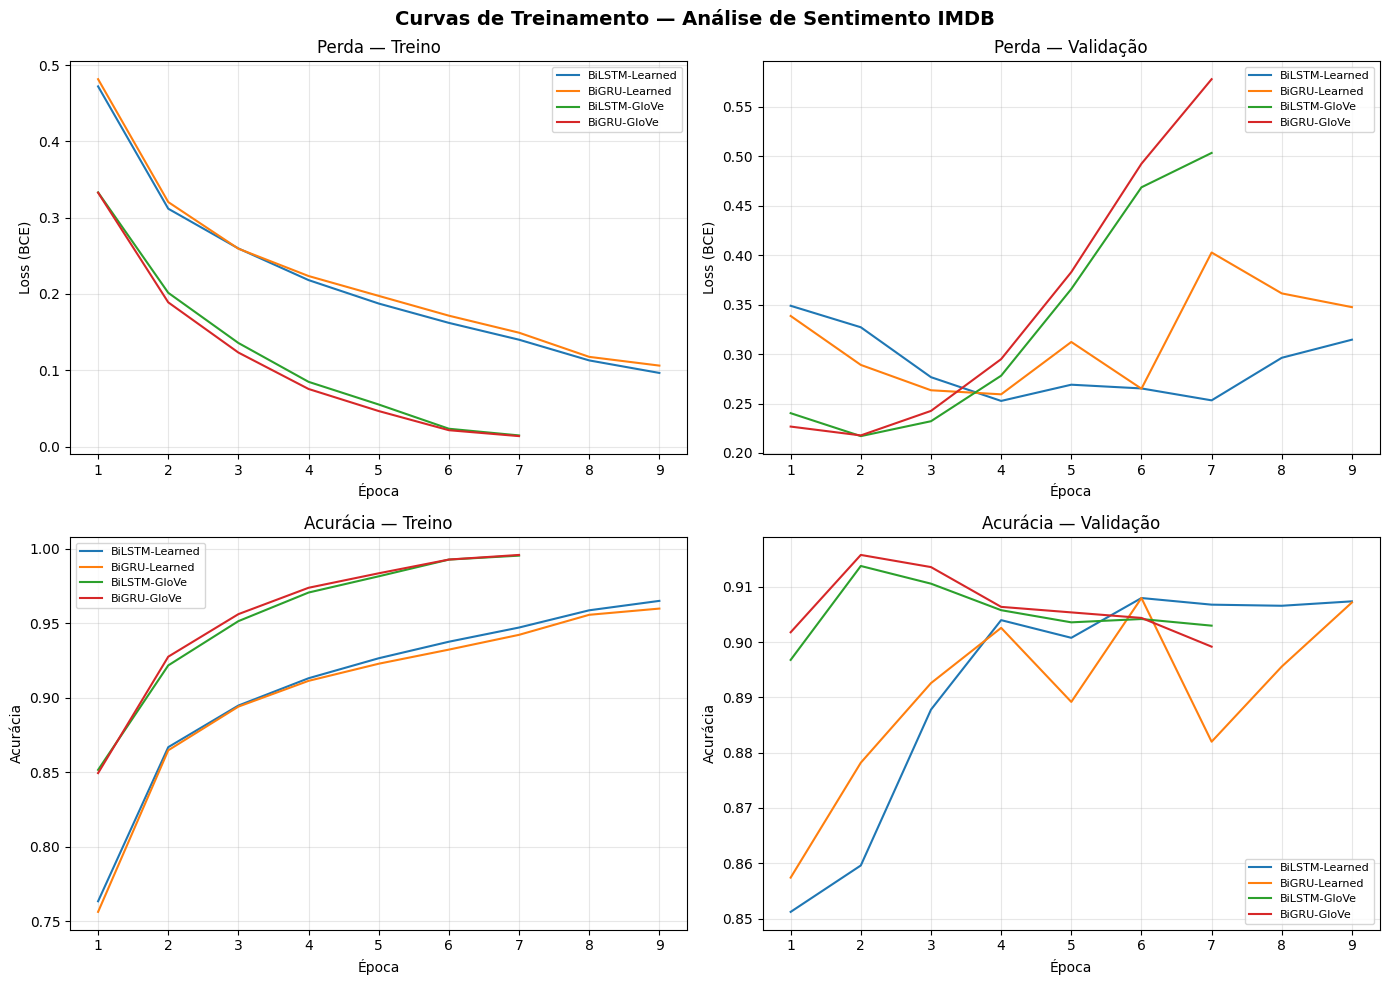

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Curvas de Treinamento — Análise de Sentimento IMDB", fontsize=14, fontweight="bold")

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, res in enumerate(results):
    name = res["config"].name
    h = res["history"]
    if not h.get("train_loss"):
        continue
    epochs = range(1, len(h["train_loss"]) + 1)
    c = colors[i]

    axes[0, 0].plot(epochs, h["train_loss"], label=name, color=c, linewidth=1.5)
    axes[0, 1].plot(epochs, h["val_loss"], label=name, color=c, linewidth=1.5)
    axes[1, 0].plot(epochs, h["train_acc"], label=name, color=c, linewidth=1.5)
    axes[1, 1].plot(epochs, h["val_acc"], label=name, color=c, linewidth=1.5)

titles = ["Perda — Treino", "Perda — Validação", "Acurácia — Treino", "Acurácia — Validação"]
y_labels = ["Loss (BCE)", "Loss (BCE)", "Acurácia", "Acurácia"]
for ax, title, ylabel in zip(axes.flat, titles, y_labels):
    ax.set_title(title)
    ax.set_xlabel("Época")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

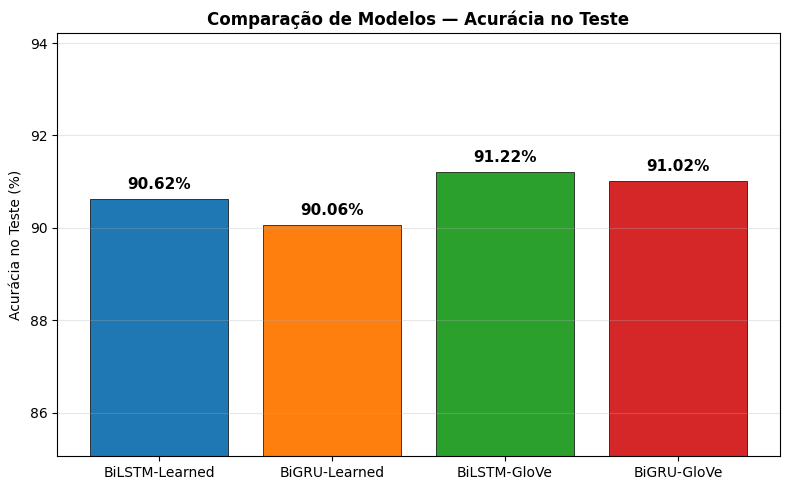

In [14]:
# Comparação de acurácia entre modelos
names = [r["config"].name for r in results]
accs = [r["test_acc"] * 100 for r in results]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, accs, color=colors[:len(names)], edgecolor="black", linewidth=0.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{acc:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)

ax.set_ylabel("Acurácia no Teste (%)")
ax.set_title("Comparação de Modelos — Acurácia no Teste", fontweight="bold")
ax.set_ylim(bottom=max(0, min(accs) - 5), top=min(100, max(accs) + 3))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Exemplos de Predições no Conjunto de Teste

5 resenhas do conjunto de teste com predição do melhor modelo (BiLSTM-GloVe).

In [15]:
best_model = max(results, key=lambda r: r["test_acc"])["model"]
best_model.eval()

label_map = {0: "negativo", 1: "positivo"}
rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(test_idx), size=min(20, len(test_idx)), replace=False)

examples = []
for si in sample_idx:
    if len(examples) >= 5:
        break
    global_idx = test_idx[si]
    tokens = tokenized[global_idx][:config.max_seq_len]
    indices = [word2idx.get(t, UNK_IDX) for t in tokens]
    padded = indices + [PAD_IDX] * (config.max_seq_len - len(indices))
    tensor = torch.tensor([padded], dtype=torch.long).to(device)

    with torch.no_grad():
        prob = best_model(tensor).item()

    pred_label = 1 if prob >= 0.5 else 0
    true_label = int(labels[global_idx])
    confidence = prob if pred_label == 1 else 1 - prob
    examples.append((global_idx, true_label, pred_label, confidence))

print("=" * 70)
print("5 EXEMPLOS DO CONJUNTO DE TESTE")
print("=" * 70)

for i, (gidx, true, pred, conf) in enumerate(examples, 1):
    review_text = original_reviews[gidx][:300].replace("\n", " ")
    if len(original_reviews[gidx]) > 300:
        review_text += "..."
    status = "CORRETO" if true == pred else "ERRADO"

    print(f"\nExemplo {i} [{status}]:")
    print(f"  Resenha: \"{review_text}\"")
    print(f"  Rótulo verdadeiro: {label_map[true]}")
    print(f"  Predição:          {label_map[pred]}")
    print(f"  Confiança:         {conf:.4f} ({conf*100:.1f}%)")

5 EXEMPLOS DO CONJUNTO DE TESTE

Exemplo 1 [CORRETO]:
  Resenha: "'The Adventures Of Barry McKenzie' started life as a satirical comic strip in 'Private Eye', written by Barry Humphries and based on an idea by Peter Cook. McKenzie ( 'Bazza' to his friends ) is a lanky, loud, hat-wearing Australian whose two main interests in life are sex ( despite never having had..."
  Rótulo verdadeiro: positivo
  Predição:          positivo
  Confiança:         0.8151 (81.5%)

Exemplo 2 [CORRETO]:
  Resenha: "For a while it seemed like this show was on 24/7. Then apparently there was a second season or some other kind of continuation of this horrible show about the two most vapid and conceited people who have ever been filmed. All the other comments have captured the essence of these two selfish, haggish..."
  Rótulo verdadeiro: negativo
  Predição:          negativo
  Confiança:         0.9903 (99.0%)

Exemplo 3 [CORRETO]:
  Resenha: "Well it's been a long year and I'm down to reviewing the final f

## 12. Resumo

| Modelo | Embeddings | Acurácia | Melhor Época | Parâmetros |
|--------|------------|----------|--------------|------------|
| BiLSTM | Aprendido-100d | 90,62% | 7 | 2.632.009 |
| BiGRU  | Aprendido-100d | 90,06% | 4 | 2.474.313 |
| **BiLSTM** | **GloVe-300d** | **91,22%** | **2** | **6.837.209** |
| BiGRU  | GloVe-300d | 91,02% | 2 | 6.628.313 |

**Observações:**
- GloVe-300d melhora ~1% sobre embeddings aprendidos e converge 2x mais rápido
- LSTM supera GRU marginalmente (~0,5%), dentro do ruído estatístico
- Self-attention + mean/max pooling supera baselines RNN típicas (~87-88%) por ~3pp
- Early stopping essencial — modelos GloVe overfittam rapidamente após época 2